## Proyecto 01_Visualización y análisis de datos. Metanólisis de amina-borano catalizada por nanopartículas M·NHC (M = Fe, Co, Ni)

**Introducción:**

La amina-borano (H₃N·BH₃) es un sólido rico en hidrógeno, propuesto como material de
almacenamiento químico de H₂. Puede sintetizarse mediante una reacción entre borohidruro de sodio y una sal de amonio, típicamente en un disolvente etéreo (como THF) con calentamiento suave (40-45 °C):

$$NaBH_4 + NH_4Cl \xrightarrow{THF,\ \Delta} H_3N{\cdot}BH_3 + NaCl + H_2$$

El NaBH₄ (barato y fácil de manejar) desplaza al cloruro, formando NaCl como subproducto
soluble que se elimina por filtración, mientras que el catión amonio y el anión borohidruro
se combinan para dar la amina-borano neutra. 

La metanólisis de amina-borano (H₃N·BH₃), esto es, su reacción con metanol en presencia de un catalizador metálico, es el proceso químico que nos interesa en este notebook. Esta reacción libera hasta **3 equivalentes de H₂ por mol de sustrato**, generando como subproducto tetrametoxiborato de amonio, NH₄B(OCH₃)₄, que fácilmente se separa del hidrógeno gaseoso generado, y además puede reciclarse para regenerar la amina-borano de partida. 

$$H_3N{\cdot}BH_3 + 4\,CH_3OH \xrightarrow{\text{catalizador}} NH_4B(OCH_3)_4 + 3\,H_2$$

Aunque existen otros procesos químicos que permiten obtener hidrógeno a partir de amina-borano, se prefiere el metanol frente al agua (hidrólisis) porque su menor punto de congelación (-98 °C frente a 0 °C) permite operar en un rango de temperaturas bajo, lo que resulta más seguro al operar con el hidrógeno gaseoso. 

Vamos a emplear python para estudiar una reacción de metanólisis de amoníaco-borano, en un caso en el que se han utilizado distintos nanomateriales como catalizadores. El sistema utilizado a nivel de laboratorio consiste en un reactor hermético, donde automáticamente se recogen los datos de presión cada 5 segundos; mediante un sensor USB que conecta el reactor con un ordenador. Posteriormente, los datos obtenidos de presión se convierten en número de moles de hidrógeno generados (P V = nRT), que se normalizan respecto a la cantidad de sustrado empleada. Los datos están recogidos en un excel. 

Los catalizadores utilizados consisten en una serie de sistemas de nanopartículas basadas en metales de la primera serie de transición (hierro, cobalto y níquel), sintetizadas a partir del método conocido como método organometálico. Este método consiste en la descomposición en condiciones suaves de un precursor organometálico que contiene al metal de interés. Si a dicha descomposición le acompaña la presencia de un agente estabilizante, como puede ser un ligando orgánico, es posible producir nanopartículas de manera muy controlada, en lo que respecta a tamaño, forma y estado superficial. En este caso, se han utilizado dos carbenos diferentes, IMes e IPr, como ligando estabilizante: 

<center>
    <img src="Sintesis_nps.png" alt="Sintesis" width="50%">
</center>


Se comenzará el análisis por uno de los nanocatalizadores de cobalto, y posteriormente se extenderá al resto de catalizadores. Los datos empleados en este notebook se corresponden con los publicados en el capítulo IV de la siguiente tesis doctoral: https://idus.us.es/items/a230d48b-70ec-4944-bb87-c8ec128b785b. Si se desea obtener más información, se adjunta bibliografía recomendada en la parte final.  

In [1]:
#Comprobemos que no hay problema al encontrar el archivo excel donde se encuentran los datos
import os
print(os.getcwd())        # Comprobemos la carpeta en la que está trabajando el jupyter notebook


C:\Users\Pablo\Desktop\Coursera\Data Science IBM\Python\Proyecto_01_Visualizacion_y_analisis_de_datos_Metanolisis_NH3BH3


In [2]:
print(os.listdir())       # Comprobemos el resto de archivos de la carpeta. No olvidar que el nombre del excel tal y como aparece aquí, es el que va en el comando df = pd.read_excel()

['.ipynb_checkpoints', 'Datos_bruto.xlsx', 'NH3BH3_Final.ipynb', 'Sintesis_nps.png']


In [3]:
import pandas as pd #Import Pandas y abrevia como pd
df = pd.read_excel("Datos_bruto.xlsx", sheet_name="CoIMES0.2") #Carga el archivo excel con los datos obtenidos en el laboratorio, empezamos por la hoja de CoIMES0.2 
factor_normalizacion = 3.0 / df['nH2/nNH3BH3'].max() #Incluimos el factor normalización para el valor máximo
print("El factor normalizacion vale ", factor_normalizacion)  #Observamos el factor de normalización que calcula Python. Debería estar en el intervalo 1.0-1.3
df['nH2/nNH3BH3_norm'] = df['nH2/nNH3BH3'] * factor_normalizacion #Incluimos una columna en la tabla que incluya el valor de H2 normalizado
print("El valor máximo de H2 generado ya normalizado es ", df['nH2/nNH3BH3_norm'].max())  # Debe estar en ≈ 3.0 equiv., el máximo de moles de H2 generados por cada mol de NH3BH3
df.head() #Veamos las primeras filas del dataframe 


El factor normalizacion vale  1.2320633288808749
El valor máximo de H2 generado ya normalizado es  2.9999999999999996


,Time / s,Pressure / bar,Temperature / °C,Unnamed: 3,t (s),t(min),Δn H2,R (atm L),T (K),V (mL),...,Unnamed: 11,nH2/nNH3BH3,Unnamed: 13,normal,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,n NH3BH3,nH2/nNH3BH3_norm
0,0.030000,1.290086,26.048375,NaN,0.000000,0.000000,0.000000,0.082,303.0,27.5,...,0.0,0.000000,NaN,0.0,NaN,NaN,NaN,NaN,1.9,0.000000
1,0.230000,1.290047,26.041096,NaN,0.200000,0.003333,-0.000042,NaN,NaN,NaN,...,NaN,-0.000022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000027
2,5.230007,1.291135,26.034357,NaN,5.200007,0.086667,0.001162,NaN,NaN,NaN,...,NaN,0.000612,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000753
3,10.230014,1.291309,26.030313,NaN,10.200014,0.170000,0.001354,NaN,NaN,NaN,...,NaN,0.000713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000878
4,15.230021,1.288904,26.014410,NaN,15.200021,0.253334,-0.001308,NaN,NaN,NaN,...,NaN,-0.000688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.000848


In [4]:
print(df.columns.tolist()) #Comprobemos los nombres que pandas interpreta de cada columna

['Time / s', 'Pressure / bar', 'Temperature / °C', 'Unnamed: 3', 't (s)', 't(min)', 'Δn H2 ', 'R (atm L)', 'T (K)', 'V (mL)', 'ΔP (bar)', 'Unnamed: 11', 'nH2/nNH3BH3', 'Unnamed: 13', 'normal', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'n NH3BH3', 'nH2/nNH3BH3_norm']


Se están representando valores de tiempo hasta el minuto: 59.753416665
Se están representando valores de hidrógeno hasta obtener 2.9999999999999996 equiv.


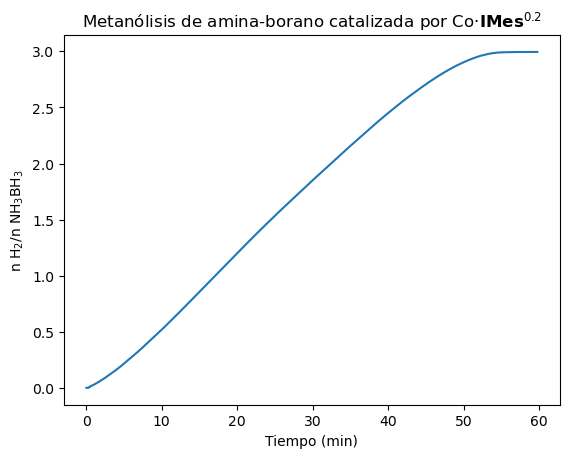

In [5]:
#Vamos a representar con matplot. Importamos la librería y abreviamos como plt
import matplotlib.pyplot as plt 

plt.plot(df['t(min)'], df['nH2/nNH3BH3_norm']) #Utilizamos las columnas t (min) y nH2/nNH3BH3_norm para representar la cantidad de hidrógeno generado normalizado respecto a la cantidad de amonia-borano y el tiempo en minutos 
plt.xlabel('Tiempo (min)') #Etiquetamos el eje del tiempo
plt.ylabel(r'n H$_2$/n NH$_3$BH$_3$') #Etiquetamos el eje del hidrógeno generado lo que ponemos entre $_y $ es para ajustar subíndices, que soy química y tengo la manía 
plt.title('Metanólisis de amina-borano catalizada por Co·$\mathbf{IMes}^{0.2}$') #Título del gráfico. Parecido a lo de antes, lo de $\mathbf{IMes}^{0.2}$ es para poner IMES en negrita y 0.2 equiv de ligando IMES con el que se ha estabilizado el cobalto en superíndice, cosas de químicos
print("Se están representando valores de tiempo hasta el minuto:", df['t(min)'].max()) #Comprobamos que pandas está leyendo el tiempo hasta el final
print("Se están representando valores de hidrógeno hasta obtener", df['nH2/nNH3BH3_norm'].max(), "equiv.") #Comprobamos el valor máximo de equiv. de H2 generados
plt.show() #Ploteamos

Muy bien, hemos comprobado que la gráfica obtenida es la deseada en el caso del primer catalizador. Como tenemos seis catalizadores, vamos a definir tres funciones de python que hagan todo lo anterior, y que el código sea más eficiente. Además, nos ayudarán a darle formato a los títulos.  

La primera función carga y normaliza los datos. 

La segunda, formatea los nombres de los catalizadores. Esto no afecta a los valores de la cinética de la reacción, pero ayudan a ponerle título al gráfico de acuerdo al formalismo químico adecuado. De cara a la escritura de artículos científicos, es un detalle importante. 

La tercera, representa gráficamente los datos, dándole títulos a los ejes y todo eso. 



In [6]:
def cargar_y_normalizar_metanólisis (nombre_hojaexcel, archivo, verbose=True): #Incluyo verbose=True para que aparezcan la información que quiero, si deseo observarla catalizador por catalizador. 
    import pandas as pd
    import matplotlib.pyplot as plt 
    df = pd.read_excel(archivo, sheet_name=nombre_hojaexcel)
    factor_normalizacion = 3.0 / df['nH2/nNH3BH3'].max()
    df['nH2/nNH3BH3_norm'] = df['nH2/nNH3BH3'] * factor_normalizacion
    if verbose:
        print("El factor normalizacion vale ", factor_normalizacion)
        print("El valor máximo de hidrógeno generado ya normalizado es ", df['nH2/nNH3BH3_norm'].max())
        print(df.columns.tolist())
    return df
def formatear_catalizador(metal, ligando, nombre_hojaexcel):
    equiv = nombre_hojaexcel.strip()[-3:]
    return rf'{metal}·$\mathbf{{{ligando}}}^{{{equiv}}}$'
def graficar_metanólisis(df, metal, ligando, nombre_hojaexcel):
    etiqueta = formatear_catalizador(metal, ligando, nombre_hojaexcel)
    plt.plot(df['t(min)'], df['nH2/nNH3BH3_norm'], label=etiqueta)
    plt.xlabel('Tiempo (min)')
    plt.ylabel(r'n H$_2$/n NH$_3$BH$_3$')

Ahora vamos a usar estas funciones con el mismo catalizador, CoIMes. 

El factor normalizacion vale  1.2320633288808749
El valor máximo de hidrógeno generado ya normalizado es  2.9999999999999996
['Time / s', 'Pressure / bar', 'Temperature / °C', 'Unnamed: 3', 't (s)', 't(min)', 'Δn H2 ', 'R (atm L)', 'T (K)', 'V (mL)', 'ΔP (bar)', 'Unnamed: 11', 'nH2/nNH3BH3', 'Unnamed: 13', 'normal', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'n NH3BH3', 'nH2/nNH3BH3_norm']


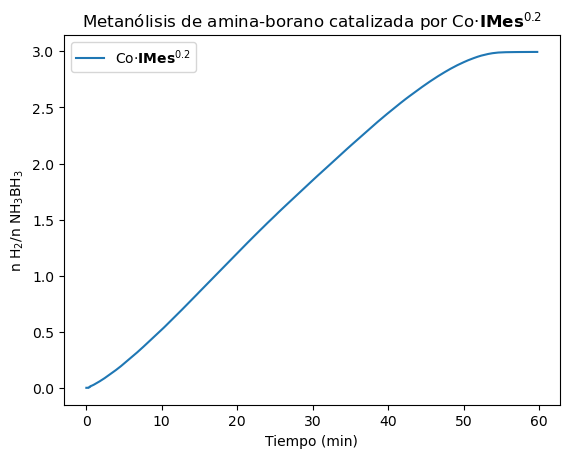

In [7]:
#Se guardará el nombre del archivo en la variable archivo para facilitar su uso.
archivo = "Datos_bruto.xlsx"  # Copiar nombre del archivo tal cual sale en print(os.listdir())
df_co_imes = cargar_y_normalizar_metanólisis("CoIMES0.2", archivo)
graficar_metanólisis(df_co_imes, "Co", "IMes", "CoIMES0.2")
plt.title(f'Metanólisis de amina-borano catalizada por {formatear_catalizador("Co", "IMes", "CoIMES0.2")}')
plt.legend()
plt.show()

Muy bien, vamos a utilizar estas funciones con cualquier otro de los seis catalizadores que se incluyen en la hoja de excel, como NiIPr

El factor normalizacion vale  1.2355148747339917
El valor máximo de hidrógeno generado ya normalizado es  3.0
['Time / s', 'Pressure / bar', 'Temperature / °C', 'Unnamed: 3', 't (s)', 't(min)', 'Δn H2 ', 'R (atm L)', 'T (K)', 'V (mL)', 'ΔP (bar)', 'Unnamed: 11', 'nH2/nNH3BH3', 'Unnamed: 13', 'normal', 'Unnamed: 15', 441.1, 10, 'Unnamed: 18', 'n NH3BH3', 'nH2/nNH3BH3_norm']


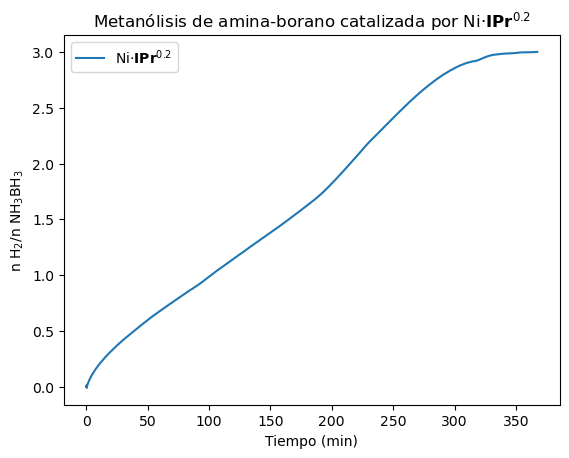

In [8]:
#Se guardará el nombre del archivo en la variable archivo para facilitar su uso.
archivo = "Datos_bruto.xlsx"  # Copiar nombre del archivo tal cual sale en print(os.listdir())
df_Ni_IPr = cargar_y_normalizar_metanólisis("NiIPr0.2", archivo)
graficar_metanólisis(df_Ni_IPr, "Ni", "IPr", "NiIPr0.2")
plt.title(f'Metanólisis de amina-borano catalizada por {formatear_catalizador("Ni", "IPr", "NiIPr0.2")}')
plt.legend()
plt.show()

Perfecto, las funciones son aplicables a otros catalizadores. Podríamos ir catalizador por catalizador hasta obtener seis gráficas, pero para facilitar la legibilidad, vamos a representarlo todo en una única gráfica comparativa. Voy a dejar el verbose=False (en lugar de en True como antes) para no tener que ver el texto correspondiente a cada catalizador, que entorpecería mucho al lector. Si es necesario obtener esos datos, se puede hacer para cada catalizador individualmente como antes.  

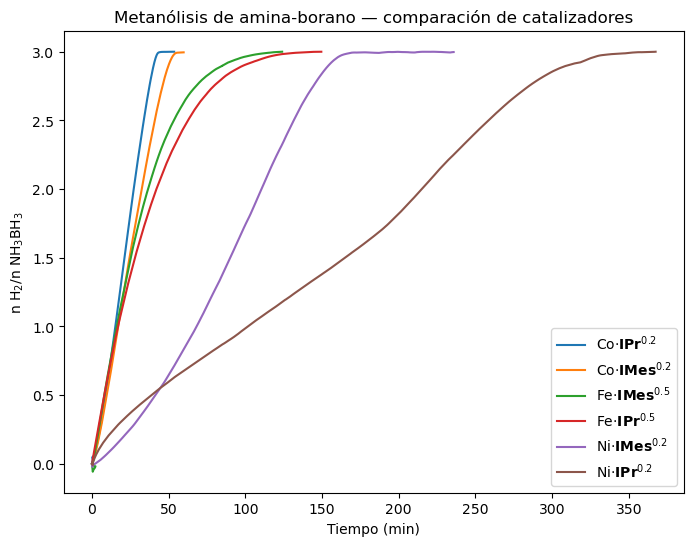

In [9]:
catalizadores = [
    ("CoIPr0.2",  "Co", "IPr"),
    ("CoIMES0.2", "Co", "IMes"),
    ("FeIMes0.5", "Fe", "IMes"),
    ("FeIPr0.5",  "Fe", "IPr"),
    ("NiIMes0.2", "Ni", "IMes"),
    ("NiIPr0.2",  "Ni", "IPr"),
]

plt.figure(figsize=(8, 6))
for nombre_hoja, metal, ligando in catalizadores:
    df = cargar_y_normalizar_metanólisis(nombre_hoja, archivo, verbose=False)
    graficar_metanólisis(df, metal, ligando, nombre_hoja)
plt.title('Metanólisis de amina-borano — comparación de catalizadores')
plt.legend()
plt.show()

Vale, a raíz de la gráfica donde se representan los seis catalizadores, es fácil observar que CoIPr es el mejor catalizador, que logra producir la máxima cantidad posible de hidrógeno en 50 minutos aproximadamente. Por este motivo, dicho catalizador se sometió a varios ciclos de reciclaje, estudio experimental que permite comprobar si el catalizador es robusto. De esta manera, si el catalizador aguanta varios ciclos, el interés económico del mismo sería mayor. Vamos a cargar la hoja de excel donde se recogieron los resultados. 

In [10]:
#Convirtamos los datos de la hoja de excel donde se guardaron los resultados del reciclaje de CoIPr en un dataframe de pandas
df_reciclajes = pd.read_excel(archivo, sheet_name="TOF reciclajes Co IPr")#Llamamos al df "df_reciclajes"
print(df_reciclajes.columns.tolist()) #Veamos el df
print(df_reciclajes)

['Unnamed: 0', 'Ciclo', 'Tiemp (s)', 'Tiemp (min)', 'TOF (min -1)']
    Unnamed: 0      Ciclo  Tiemp (s)  Tiemp (min)  TOF (min -1)
0          NaN          1     1800.0    30.000000     29.400000
1          NaN          2     2400.0    40.000000     22.050000
2          NaN          3     1700.0    28.333333     31.129412
3          NaN          4     2150.0    35.833333     24.613953
4          NaN          5     1600.0    26.666667     33.075000
5          NaN          6     1900.0    31.666667     27.852632
6          NaN          7     1900.0    31.666667     27.852632
7          NaN          8     3100.0    51.666667     17.070968
8          NaN          9     2400.0    40.000000     22.050000
9          NaN         10     3700.0    61.666667     14.302703
10         NaN        NaN        NaN          NaN           NaN
11         NaN        NaN        NaN          NaN           NaN
12         NaN  S/C = 294        NaN          NaN           NaN
13         NaN        294        NaN

Hay que limpiar un poco estos datos, la primera columna está vacía, y como el catalizador sólo se sometió a diez ciclos de reciclaje, todas las filas en adelante también lo están. Hay varios valores que muestran una relación sustrato/catalizador "S/C = 294", parece que fueron anotaciones sobre las condiciones de reacción realizadas por el experimentador sobre el propio excel en el momento que se recogieron los datos. También se deberían borrar del DF, se incluirán posteriormente en los títulos del gráfico. 


In [11]:
df_reciclajes = df_reciclajes.drop(columns=['Unnamed: 0']) #Quitamos toda la primera columna
df_reciclajes = df_reciclajes.dropna(subset=['TOF (min -1)']) #Quitamos toda las filas a partir del 10º reciclaje
df_reciclajes['Ciclo'] = df_reciclajes['Ciclo'].astype(int) #Queremos que el valor del Nº de Ciclo sea un int, de cara a representar datos

print(df_reciclajes) #Veamos como queda el df tras limpiar un poco

   Ciclo  Tiemp (s)  Tiemp (min)  TOF (min -1)
0      1     1800.0    30.000000     29.400000
1      2     2400.0    40.000000     22.050000
2      3     1700.0    28.333333     31.129412
3      4     2150.0    35.833333     24.613953
4      5     1600.0    26.666667     33.075000
5      6     1900.0    31.666667     27.852632
6      7     1900.0    31.666667     27.852632
7      8     3100.0    51.666667     17.070968
8      9     2400.0    40.000000     22.050000
9     10     3700.0    61.666667     14.302703


Muy bien, teniendo el df limpio, vamos a representar estos datos en un gráfico de barras con matplot. Representaremos el valor de TOF o TurnOver Frequency (un parámetro estándar de comparación de catalizadores, la eficiencia del catalizador por unidad de tiempo es mayor para valores altos de TOF) vs número de ciclo, hasta llegar a 10. 

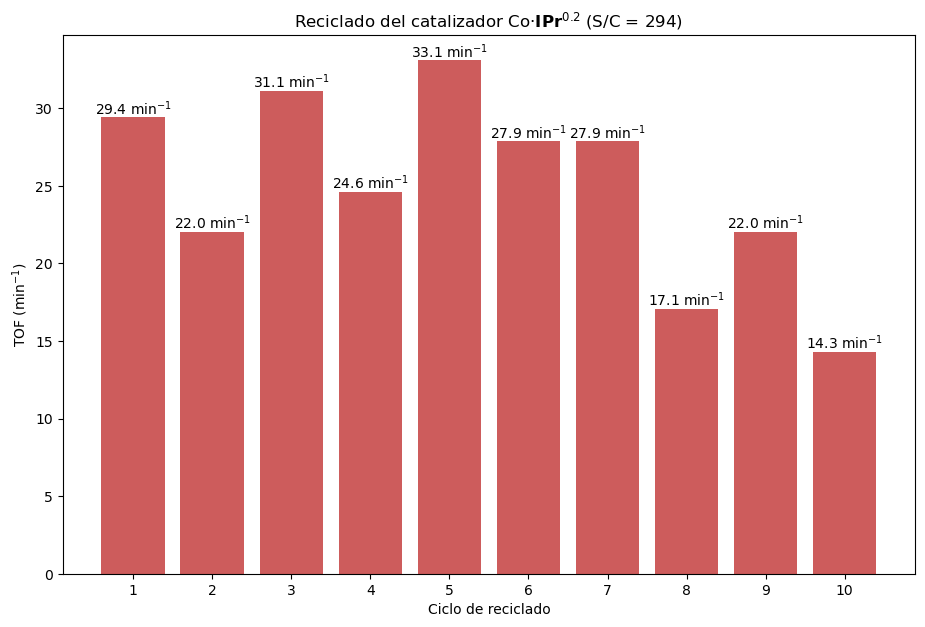

In [12]:
plt.figure(figsize=(11, 7))#Ajustamos el tamaño del gráfico
barras = plt.bar(df_reciclajes['Ciclo'], df_reciclajes['TOF (min -1)'], color='indianred') #Guardamos el resultado de plotear un la variable barras, que se utilizará para etiquetar cada ciclo. Además, especificamos el df del que se toman los valores de ambos ejes y ponemos un color suave, por facilidad visual para el lector
plt.xlabel('Ciclo de reciclado') #Etiquetamos el eje x
plt.ylabel(r'TOF (min$^{-1}$)') #Etiquetamos el eje y, damos formato a las unidades para que el superíndice esté correcto
plt.title(r'Reciclado del catalizador Co·$\mathbf{IPr}^{0.2}$ (S/C = 294)') #Titulamos el gráfico, no olvidemos la relación S/C, respecto a las condiciones experimentales
plt.xticks(df_reciclajes['Ciclo']) #Obligamos a que en el gráfico de barras aparezcan los diez valores para cada ciclo
plt.bar_label(barras, fmt=r'%.1f min$^{-1}$') #Utilizamos la variable barras para etiquetar cada una de ellas, y formateamos las unidades para que los superíndices estén correctos
plt.show() #Ploteamos

En la gráfica anterior puede observarse que el valor inicial de TOF se sitúa en 29.4 min-1, mientras que para el décimo ciclo, su valor es de 14.3 min-1. Aunque para la última etapa, el nanocatalizador ha perdido un 51.4% de su capacidad catalítica, es interesante observar que, si bien hay oscilaciones en los valores exactos que podrían asociarse a errores experimentales, en cualquier caso la caída no es lineal. Por ejemplo, en el séptimo ciclo (TOF = 27.9 min-1) se conserva hasta un 94.7% del valor original de TOF. Se trata de un nivel de reutilización muy sólido para un catalizador de estas características, teniendo en cuenta que en la bibliografía están reportados valores de conservación de en torno al 70-85% del TOF original para nanomateriales comparables (Ver referencias 4 y 5). 

**Referencias:**
1. Ramachandran, P. V.; Gagare, P. D. *Preparation of Ammonia Borane in High Yield and
  Purity, Methanolysis, and Regeneration.* Inorg. Chem. **2007**, 46, 7810–7817.
  [https://doi.org/10.1021/ic700772a](https://doi.org/10.1021/ic700772a) — primer precedente
  publicado de la metanólisis de amina-borano.
2. Staubitz, A.; Robertson, A. P. M.; Manners, I. *Ammonia-Borane and Related Compounds as
  Dihydrogen Sources.* Chem. Rev. **2010**, 110, 4079–4124.
  [https://doi.org/10.1021/cr100088b](https://doi.org/10.1021/cr100088b) — review de
  referencia sobre métodos de deshidrogenación de amina-borano (termólisis, hidrólisis,
  metanólisis).
3. Kang, N.; Wang, C.; Astruc, D. *Hydrogen Evolution upon Ammonia Borane Solvolysis:
  Comparison between the Hydrolysis and Methanolysis Reactions.* Chemistry **2023**, 5,
  886–899. [https://doi.org/10.3390/chemistry5020060](https://doi.org/10.3390/chemistry5020060)
  — acceso abierto, comparación directa hidrólisis vs. metanólisis.
4. Lara, P.; Philippot, K.; Suárez, A. *Platinum Nanoparticles Stabilized by Terphenylphosphane
  Ligands: Synthesis and Application in the Catalytic Hydrogen Generation from Ammonia-Borane.*
  ChemCatChem **2019**, 11, 766–771.
  [https://doi.org/10.1002/cctc.201801702](https://doi.org/10.1002/cctc.201801702) —
  nanopartículas de Pt, con TOF de hasta 283 min⁻¹ y estudios
  de reusabilidad, directamente comparable con los catalizadores Co/Fe/Ni de este proyecto.
5. Caner, N.; Yurderi, M.; Bulut, A.; Kanberoglu, G. S.; Kaya, M.; Zahmakiran, M. *Chromium
  Based Metal–Organic Framework MIL-101 Decorated Palladium Nanoparticles for the Methanolysis
  of Ammonia-Borane.* New J. Chem. **2020**, 44, 12435–12439.
  [https://doi.org/10.1039/D0NJ01931C](https://doi.org/10.1039/D0NJ01931C) — catalizador de
  Pd soportado con actividad récord (TOF = 1080 min⁻¹) y buena estabilidad como catalizador
  reutilizable.
6. Chaudret, B. *Organometallic approach to nanoparticles synthesis and self-organization.* Comptes Rendus Physique. **2005**, 6, 117-131. [https://doi.org/10.1016/j.crhy.2004.11.008](https://doi.org/10.1016/j.crhy.2004.11.008)-Método organometálico de síntesis de nanopartículas.
7. Molinillo Fernández, P. *Metal nanoparticles (Fe, Co, Ni, Ru) stabilised by SNS and NHC ligands. Synthesis, Characterisation and Catalytic Applications.* Tesis Doctoral, Universidad de Sevilla, **2025**. [https://idus.us.es/items/a230d48b-70ec-4944-bb87-c8ec128b785b](https://idus.us.es/items/a230d48b-70ec-4944-bb87-c8ec128b785b)— Capítulo IV: metanólisis de amina-borano catalizada por nanopartículas de Fe, Co y Ni, fuente original de los datos usados en este notebook.